In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error

1. LOAD DATA

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [3]:
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


2. DATA PREPARATION

In [6]:
# Handle missing values (if any)
df.fillna(df.median(numeric_only=True), inplace=True)

3. EDA - Long Tail Detection

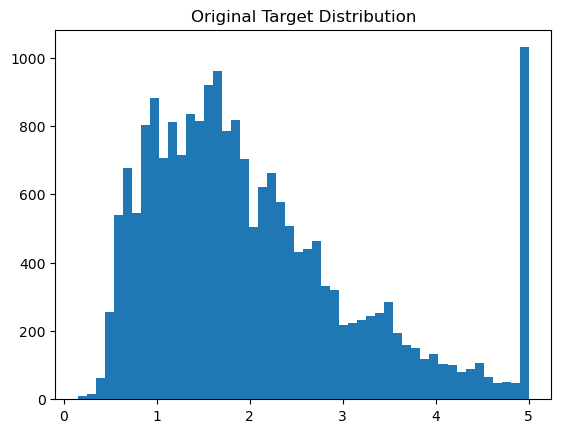

In [7]:
plt.hist(df["MedHouseVal"], bins=50)
plt.title("Original Target Distribution")
plt.show()

In [8]:
# Log normalization (long tail)
df["MedHouseVal"] = np.log1p(df["MedHouseVal"])

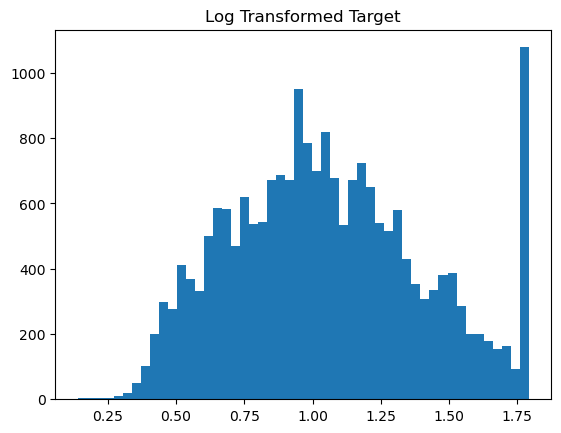

In [9]:
plt.hist(df["MedHouseVal"], bins=50)
plt.title("Log Transformed Target")
plt.show()

4. FEATURE ENGINEERING

In [10]:
df["RoomsPerHousehold"] = df["AveRooms"] / df["HouseAge"]
df["BedroomsPerRoom"] = df["AveBedrms"] / df["AveRooms"]

In [11]:
# Create categorical feature
df["IncomeLevel"] = pd.qcut(df["MedInc"], 4, labels=["Low", "Medium", "High", "VeryHigh"])

5. TRAIN / VALIDATION / TEST SPLIT

In [14]:
train_full, test = train_test_split(df, test_size=0.2, random_state=42)
train, val = train_test_split(train_full, test_size=0.2, random_state=42)

In [15]:
X_train = train.drop("MedHouseVal", axis=1)
y_train = train["MedHouseVal"]

In [16]:
X_val = val.drop("MedHouseVal", axis=1)
y_val = val["MedHouseVal"]

In [17]:
X_test = test.drop("MedHouseVal", axis=1)
y_test = test["MedHouseVal"]

6. ONE-HOT ENCODING

In [18]:
encoder = OneHotEncoder(sparse_output=False)
encoded_train = encoder.fit_transform(X_train[["IncomeLevel"]])
encoded_val = encoder.transform(X_val[["IncomeLevel"]])
encoded_test = encoder.transform(X_test[["IncomeLevel"]])

In [19]:
num_features = X_train.drop("IncomeLevel", axis=1)

In [20]:
X_train_num = num_features
X_val_num = X_val.drop("IncomeLevel", axis=1)
X_test_num = X_test.drop("IncomeLevel", axis=1)

In [21]:
X_train_final = np.hstack([X_train_num, encoded_train])
X_val_final = np.hstack([X_val_num, encoded_val])
X_test_final = np.hstack([X_test_num, encoded_test])

7. STANDARDIZATION

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_val_final)
X_test_scaled = scaler.transform(X_test_final)

8. LINEAR REGRESSION (FROM SCRATCH)

In [24]:
def add_bias(X):
    return np.c_[np.ones((X.shape[0], 1)), X]

In [25]:
def normal_equation(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

In [26]:
def predict(X, theta):
    return X @ theta

In [27]:
X_train_b = add_bias(X_train_scaled)
X_val_b = add_bias(X_val_scaled)
X_test_b = add_bias(X_test_scaled)


In [28]:
theta = normal_equation(X_train_b, y_train.values)

In [29]:
val_preds = predict(X_val_b, theta)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print("Linear Regression RMSE:", rmse)

Linear Regression RMSE: 0.2140595710918595


9. REGULARIZATION (RIDGE FROM SCRATCH)

In [30]:
def ridge_normal_equation(X, y, alpha):
    n = X.shape[1]
    I = np.eye(n)
    I[0, 0] = 0  # don't regularize bias
    return np.linalg.inv(X.T @ X + alpha * I) @ X.T @ y

In [31]:
alphas = [0.01, 0.1, 1, 10, 100]
best_alpha = None
best_rmse = float("inf")

In [32]:
for alpha in alphas:
    theta_ridge = ridge_normal_equation(X_train_b, y_train.values, alpha)
    val_preds = predict(X_val_b, theta_ridge)
    rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    print(f"Alpha: {alpha}, RMSE: {rmse}")

Alpha: 0.01, RMSE: 0.21351540913747277
Alpha: 0.1, RMSE: 0.2135151726097871
Alpha: 1, RMSE: 0.21351285729911076
Alpha: 10, RMSE: 0.21349455734069128
Alpha: 100, RMSE: 0.2136819654793342


In [33]:
  if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = alpha

In [34]:
print("Best alpha:", best_alpha)

Best alpha: 100


10. FINAL MODEL

In [35]:
X_combined = np.vstack([X_train_scaled, X_val_scaled])
y_combined = np.concatenate([y_train, y_val])

X_combined_b = add_bias(X_combined)

final_theta = ridge_normal_equation(X_combined_b, y_combined, best_alpha)

test_preds = predict(X_test_b, final_theta)
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

print("Final Test RMSE:", test_rmse)

Final Test RMSE: 0.21526322934538505


In [36]:
print("Answer: 0.21526322934538505")

Answer: 0.21526322934538505


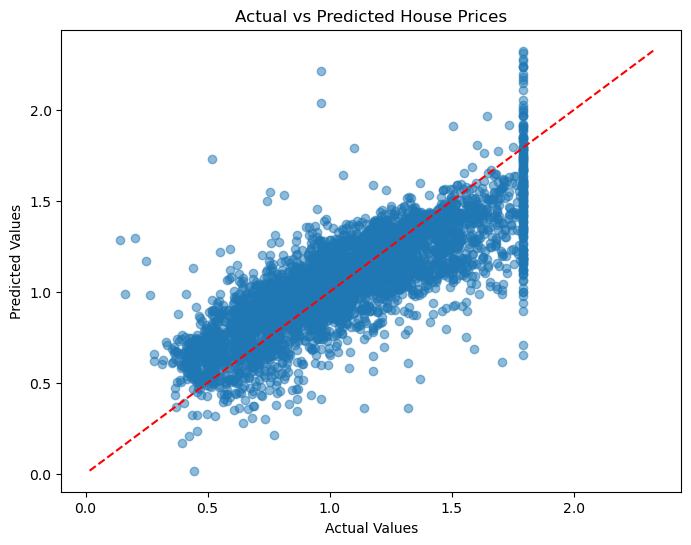

In [47]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_preds, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Prices")

min_val = min(y_test.min(), test_preds.min())
max_val = max(y_test.max(), test_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.show()